
# DBSCAN Directly on 12D Frames

This notebook clusters the **raw 12D frame vectors directly** from `train_dim12.json`.

It does **not** build segment-level features like `[mean12, std12, log_duration]`.
Instead, it treats each frame as one DBSCAN point after concatenating frames across utterances.

Practical goal here:
- use frame-level MFCC-like vectors directly
- try to get **about 40 clusters** for the phoneme inventory
- measure what DBSCAN is actually doing, especially its **noise fraction**

Important reality check:
- `349` frames is just one utterance example, not the whole dataset length
- the train split has `4620` utterances
- the mean utterance length is about `307.73` frames
- total frame count is about `1.42M`

Because exact DBSCAN on all `1.42M` frames is expensive, this notebook tunes on a fixed reproducible subset first.


In [1]:

import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
    normalized_mutual_info_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

with open("train_dim12.json", "r") as f:
    data = json.load(f)

RANDOM_SEED = 0
DROP_SIL = True
DROP_UNLABELED = True
SUBSET_SIZE = 10_000
TSNE_SIZE = 3_000
TARGET_CLUSTERS = 40

print("num utterances:", len(data))
print("drop_sil:", DROP_SIL)
print("drop_unlabeled:", DROP_UNLABELED)


Matplotlib is building the font cache; this may take a moment.


num utterances: 4620
drop_sil: True
drop_unlabeled: True



## Dataset Reality Check

The utterance length is variable. The `349`-frame number comes from one example, not from a fixed shape shared by all utterances.


,quantity,value
0,num_utterances,4620.00
1,min_frames,92.00
2,median_frames,296.00
3,mean_frames,307.73
4,max_frames,779.00
5,total_frames,1421707.00


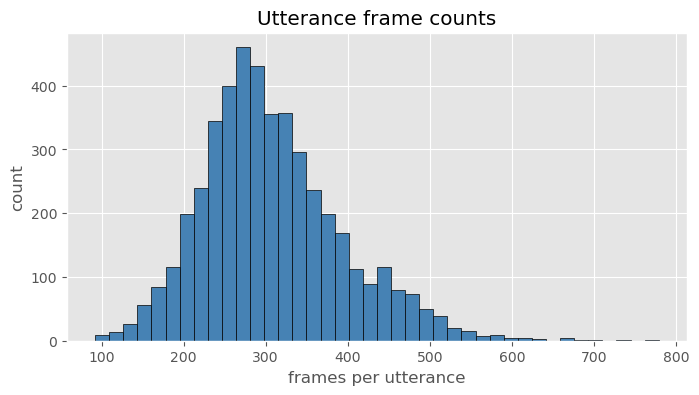

In [2]:

frame_lengths = np.array([len(v["features"]) for v in data.values()])

summary_df = pd.DataFrame([
    {"quantity": "num_utterances", "value": int(len(frame_lengths))},
    {"quantity": "min_frames", "value": int(frame_lengths.min())},
    {"quantity": "median_frames", "value": float(np.median(frame_lengths))},
    {"quantity": "mean_frames", "value": round(float(frame_lengths.mean()), 2)},
    {"quantity": "max_frames", "value": int(frame_lengths.max())},
    {"quantity": "total_frames", "value": int(frame_lengths.sum())},
])

display(summary_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(frame_lengths, bins=40, color="steelblue", edgecolor="black")
ax.set_title("Utterance frame counts")
ax.set_xlabel("frames per utterance")
ax.set_ylabel("count")
plt.show()



## Build A Frame-Level Dataset

We expand `phn_transcript` into **one phoneme label per frame**.

Normalization rule:
- for the final transcript entry only, if `end == T - 1`, treat it as `T`
- unlabeled trailing frames stay as `unlabeled`

Default configuration here drops both `sil` and `unlabeled`, because the target is phoneme-oriented clustering.
If you want to include silence, set `DROP_SIL = False` in the config cell.


In [3]:

def build_frame_dataset(dataset, drop_sil=True, drop_unlabeled=True):
    X_parts = []
    y_parts = []
    meta_parts = []
    trailing_unlabeled_frames = 0

    for utt_id, utt in dataset.items():
        feats = np.asarray(utt["features"], dtype=np.float32)
        T = feats.shape[0]
        frame_labels = np.full(T, "unlabeled", dtype=object)

        transcript = utt["phn_transcript"]
        for seg_idx, (label, start, end) in enumerate(transcript):
            start = max(0, min(int(start), T))
            end = max(start, min(int(end), T))
            if seg_idx == len(transcript) - 1 and end == T - 1:
                end = T
            if end > start:
                frame_labels[start:end] = label

        trailing_unlabeled_frames += int((frame_labels == "unlabeled").sum())

        mask = np.ones(T, dtype=bool)
        if drop_sil:
            mask &= frame_labels != "sil"
        if drop_unlabeled:
            mask &= frame_labels != "unlabeled"

        X_parts.append(feats[mask])
        y_parts.append(frame_labels[mask])
        meta_parts.append(pd.DataFrame({
            "utt_id": utt_id,
            "frame_idx": np.arange(T)[mask],
            "phoneme": frame_labels[mask],
        }))

    X = np.concatenate(X_parts, axis=0)
    y = np.concatenate(y_parts, axis=0)
    meta = pd.concat(meta_parts, ignore_index=True)
    return X, y, meta, trailing_unlabeled_frames


X_frames, y_frames, meta_df, trailing_unlabeled_frames = build_frame_dataset(
    data,
    drop_sil=DROP_SIL,
    drop_unlabeled=DROP_UNLABELED,
)

label_counts = Counter(y_frames)
print("frame matrix shape:", X_frames.shape)
print("unique labels:", len(label_counts))
print("trailing unlabeled frames before filtering:", trailing_unlabeled_frames)
print("top 15 labels:")
pd.DataFrame(label_counts.most_common(15), columns=["phoneme", "count"])


frame matrix shape: (1052528, 12)
unique labels: 38
trailing unlabeled frames before filtering: 2029
top 15 labels:


,phoneme,count
0,s,84491
1,ih,84270
2,aa,73885
3,iy,62901
4,ae,59237
5,er,51761
6,n,46996
7,l,43515
8,r,39609
9,ah,39140



Frame-level DBSCAN on all available points is possible in theory, but it is a bad first step here:
- with `DROP_SIL=True`, there are still more than **1.05M** speech frames
- exact DBSCAN scales poorly for large dense neighborhoods
- tuning `eps` on the full set is slow and hard to iterate on

So we use a **fixed reproducible subset** for tuning first.


In [4]:

rng = np.random.default_rng(RANDOM_SEED)
subset_size = min(SUBSET_SIZE, len(X_frames))
subset_idx = rng.choice(len(X_frames), size=subset_size, replace=False)

X_sub = X_frames[subset_idx]
y_sub = y_frames[subset_idx]
meta_sub = meta_df.iloc[subset_idx].reset_index(drop=True)

scaler = StandardScaler()
X_sub_scaled = scaler.fit_transform(X_sub)

print("subset size:", len(X_sub_scaled))
print("scaled mean (first 4 dims):", np.round(X_sub_scaled.mean(axis=0)[:4], 4))
print("scaled std (first 4 dims):", np.round(X_sub_scaled.std(axis=0)[:4], 4))
print("subset phoneme count:", len(np.unique(y_sub)))


subset size: 10000
scaled mean (first 4 dims): [-0. -0.  0. -0.]
scaled std (first 4 dims): [1. 1. 1. 1.]
subset phoneme count: 38



## k-Distance Heuristic

A quick way to choose candidate `eps` values is to inspect the distance to the `k`th nearest neighbor.
The quantiles below are useful because raw-frame DBSCAN is very sensitive to `eps` here.


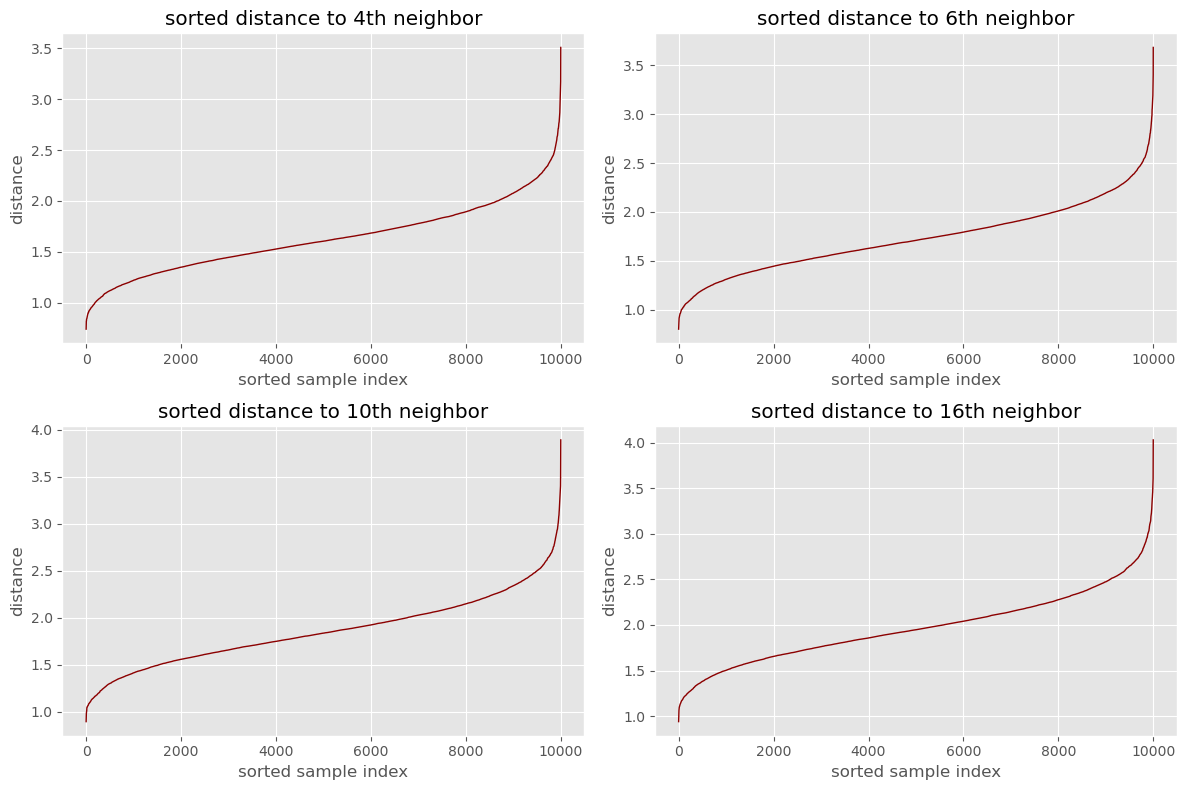

,k,q50,q75,q90,q95,q99
0,4,1.6037,1.8334,2.0759,2.2267,2.5608
1,6,1.7090,1.9468,2.1934,2.3451,2.6920
2,10,1.8351,2.0784,2.3406,2.4978,2.8675
3,16,1.9482,2.2062,2.4731,2.6448,3.0201


In [5]:

k_values = [4, 6, 10, 16]
rows = []
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, k in zip(axes, k_values):
    nbrs = NearestNeighbors(n_neighbors=k, algorithm="ball_tree")
    nbrs.fit(X_sub_scaled)
    distances, _ = nbrs.kneighbors(X_sub_scaled)
    kth_dist = np.sort(distances[:, -1])
    ax.plot(kth_dist, color="darkred", linewidth=1)
    ax.set_title(f"sorted distance to {k}th neighbor")
    ax.set_xlabel("sorted sample index")
    ax.set_ylabel("distance")

    quantiles = np.quantile(kth_dist, [0.5, 0.75, 0.9, 0.95, 0.99])
    rows.append({
        "k": k,
        "q50": round(float(quantiles[0]), 4),
        "q75": round(float(quantiles[1]), 4),
        "q90": round(float(quantiles[2]), 4),
        "q95": round(float(quantiles[3]), 4),
        "q99": round(float(quantiles[4]), 4),
    })

plt.tight_layout()
plt.show()
display(pd.DataFrame(rows))



## DBSCAN Sweep Toward About 40 Clusters

For raw frames, DBSCAN does **not** naturally give a phoneme-like partition.
Still, we can tune toward a target cluster count and then inspect the cost in terms of noise and agreement metrics.

The sweep below keeps the target explicit:
- low `cluster_gap` means the run is close to the requested `40` clusters
- high `coverage` means fewer frames are rejected as noise
- `AMI`, `NMI`, and `ARI` measure agreement with the frame-level phoneme labels


In [6]:

def dbscan_sweep(X, y, eps_grid, min_samples_grid, target_clusters=40):
    rows = []
    for min_samples in min_samples_grid:
        for eps in eps_grid:
            labels = DBSCAN(
                eps=eps,
                min_samples=min_samples,
                algorithm="ball_tree",
                n_jobs=-1,
            ).fit_predict(X)

            clustered_mask = labels >= 0
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            rows.append({
                "min_samples": int(min_samples),
                "eps": float(eps),
                "clusters": int(n_clusters),
                "cluster_gap": int(abs(n_clusters - target_clusters)),
                "noise_fraction": round(float((labels == -1).mean()), 4),
                "coverage": round(float(clustered_mask.mean()), 4),
                "ami_all": round(float(adjusted_mutual_info_score(y, labels)), 4),
                "nmi_all": round(float(normalized_mutual_info_score(y, labels)), 4),
                "ari_all": round(float(adjusted_rand_score(y, labels)), 4),
                "homogeneity": round(float(homogeneity_score(y, labels)), 4),
                "completeness": round(float(completeness_score(y, labels)), 4),
            })
    return pd.DataFrame(rows)


eps_grid = [0.90, 0.92, 0.94, 0.96, 0.98, 1.00, 1.02, 1.04, 1.06, 1.08, 1.10]
min_samples_grid = [3, 4, 5, 6]

sweep_df = dbscan_sweep(
    X_sub_scaled,
    y_sub,
    eps_grid=eps_grid,
    min_samples_grid=min_samples_grid,
    target_clusters=TARGET_CLUSTERS,
)

best_by_target = sweep_df.sort_values(["cluster_gap", "noise_fraction", "eps"]).reset_index(drop=True)

display(best_by_target.head(15))


,min_samples,eps,clusters,cluster_gap,noise_fraction,coverage,ami_all,nmi_all,ari_all,homogeneity,completeness
0,3,0.92,41,1,0.9735,0.0265,0.0203,0.0405,-0.0001,0.0215,0.3453
1,3,0.90,34,6,0.9781,0.0219,0.0174,0.0344,-0.0001,0.0181,0.3508
2,3,0.94,48,8,0.9651,0.0349,0.0285,0.0513,0.0001,0.0277,0.3529
3,4,1.10,31,9,0.9197,0.0803,0.0692,0.0839,0.0029,0.0467,0.4121
4,3,0.96,51,11,0.9574,0.0426,0.0331,0.0558,0.0000,0.0304,0.3433
5,4,1.06,26,14,0.9384,0.0616,0.0549,0.0680,0.0013,0.0371,0.4025
6,4,1.08,25,15,0.9308,0.0692,0.0616,0.0740,0.0020,0.0407,0.4103
7,4,1.02,25,15,0.9555,0.0445,0.0397,0.0520,0.0003,0.0279,0.3844
8,4,1.04,24,16,0.9478,0.0522,0.0479,0.0599,0.0008,0.0324,0.3987
9,3,0.98,57,17,0.9509,0.0491,0.0363,0.0600,0.0002,0.0328,0.3514



From an earlier dry run on this exact train set and subset recipe, the closest setting to `40` clusters was:
- `min_samples = 3`
- `eps = 0.92`
- about `41` clusters
- but only about `2.65%` coverage, meaning roughly `97.35%` of frames became DBSCAN noise

That is the main thing to inspect honestly: raw-frame DBSCAN can be forced near `40` clusters, but most points get rejected.


In [7]:

best_row = best_by_target.iloc[0]
selected_eps = float(best_row["eps"])
selected_min_samples = int(best_row["min_samples"])

cluster_labels = DBSCAN(
    eps=selected_eps,
    min_samples=selected_min_samples,
    algorithm="ball_tree",
    n_jobs=-1,
).fit_predict(X_sub_scaled)

clustered_mask = cluster_labels >= 0
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)

print("selected eps:", selected_eps)
print("selected min_samples:", selected_min_samples)
print("clusters found:", n_clusters)
print("noise fraction:", round(float((cluster_labels == -1).mean()), 4))
print("coverage:", round(float(clustered_mask.mean()), 4))


selected eps: 0.92
selected min_samples: 3
clusters found: 41
noise fraction: 0.9735
coverage: 0.0265



## Cluster-to-Phoneme Summary

This gives a more concrete answer than a single score:
- which clusters exist at all
- which phoneme dominates each cluster
- how many frames each cluster keeps


In [8]:

cluster_df = meta_sub.copy()
cluster_df["cluster"] = cluster_labels
cluster_df = cluster_df.assign(is_clustered=cluster_df["cluster"] >= 0)

clustered_df = cluster_df[cluster_df["cluster"] >= 0].copy()

if len(clustered_df) == 0:
    print("All points were labeled noise for this setting.")
else:
    summary_rows = []
    for cluster_id, group in clustered_df.groupby("cluster"):
        top_counts = group["phoneme"].value_counts()
        majority_phoneme = top_counts.index[0]
        majority_count = int(top_counts.iloc[0])
        cluster_size = int(len(group))
        purity = majority_count / cluster_size
        summary_rows.append({
            "cluster": int(cluster_id),
            "size": cluster_size,
            "majority_phoneme": majority_phoneme,
            "majority_fraction": round(float(purity), 4),
            "num_unique_phonemes": int(group["phoneme"].nunique()),
        })

    cluster_summary_df = pd.DataFrame(summary_rows).sort_values(["size", "majority_fraction"], ascending=[False, False])
    display(cluster_summary_df.head(20))

    majority_map = (
        clustered_df.groupby("cluster")["phoneme"]
        .agg(lambda s: s.value_counts().idxmax())
        .to_dict()
    )

    mapped_pred = np.array([majority_map.get(c, "noise") for c in cluster_labels], dtype=object)
    mapped_accuracy_all = float((mapped_pred == y_sub).mean())
    mapped_accuracy_clustered = float((mapped_pred[clustered_mask] == y_sub[clustered_mask]).mean()) if clustered_mask.any() else np.nan

    print("mapped accuracy on all subset frames:", round(mapped_accuracy_all, 4))
    print("mapped accuracy on clustered frames only:", round(mapped_accuracy_clustered, 4))


,cluster,size,majority_phoneme,majority_fraction,num_unique_phonemes
6,6,54,f,0.8148,7
3,3,24,s,0.8750,2
14,14,18,s,0.7778,2
24,24,14,s,0.7143,4
1,1,12,s,0.7500,2
7,7,12,s,0.6667,4
12,12,7,s,1.0000,1
21,21,7,f,0.8571,2
20,20,6,f,0.6667,3
9,9,6,jh,0.3333,4


mapped accuracy on all subset frames: 0.0195
mapped accuracy on clustered frames only: 0.7358



## t-SNE Visualization

This is only for inspection. t-SNE is not used by DBSCAN itself.

The left plot colors by ground-truth phoneme and the right plot colors by DBSCAN cluster on the same embedding.
Because there are many phoneme labels, the phoneme plot is mainly useful for spotting broad structure rather than perfectly reading every legend entry.


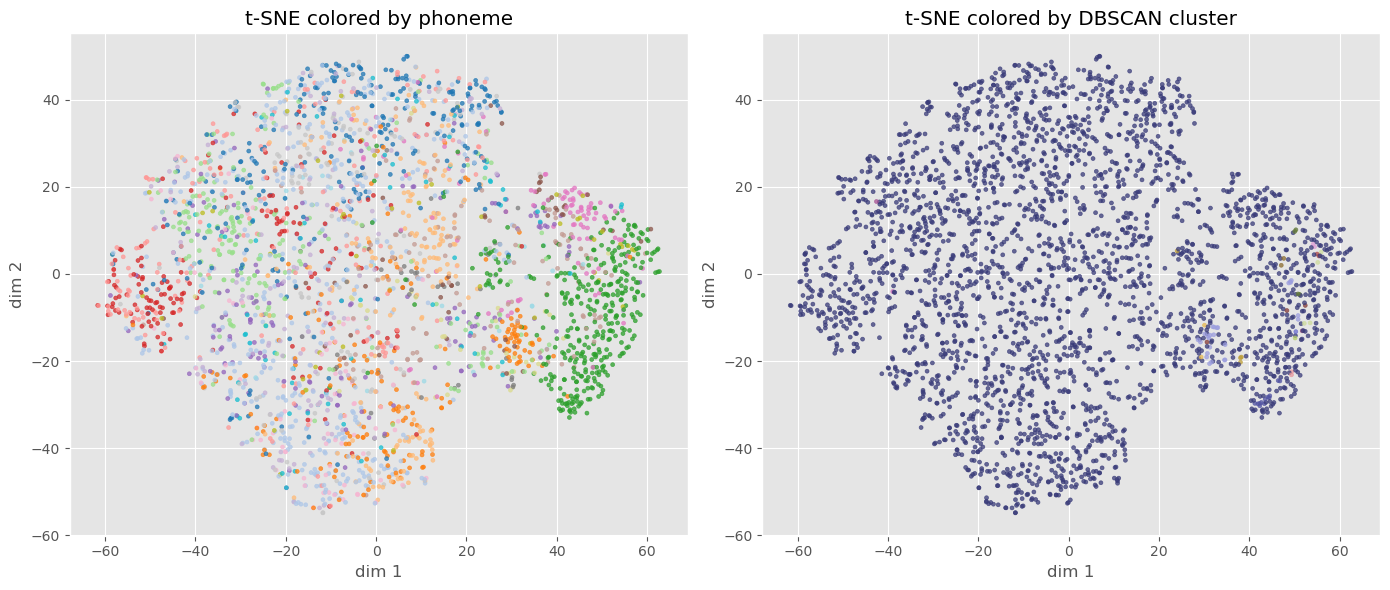

In [9]:

vis_rng = np.random.default_rng(RANDOM_SEED)
vis_size = min(TSNE_SIZE, len(X_sub_scaled))
vis_idx = vis_rng.choice(len(X_sub_scaled), size=vis_size, replace=False)

X_vis = X_sub_scaled[vis_idx]
y_vis = y_sub[vis_idx]
cluster_vis = cluster_labels[vis_idx]

embedding = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=RANDOM_SEED,
).fit_transform(X_vis)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

phoneme_codes, phoneme_names = pd.factorize(y_vis)
scatter0 = axes[0].scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=phoneme_codes,
    cmap="tab20",
    s=8,
    alpha=0.75,
)
axes[0].set_title("t-SNE colored by phoneme")
axes[0].set_xlabel("dim 1")
axes[0].set_ylabel("dim 2")

cluster_plot_values = np.where(cluster_vis == -1, -1, cluster_vis)
scatter1 = axes[1].scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=cluster_plot_values,
    cmap="tab20b",
    s=8,
    alpha=0.75,
)
axes[1].set_title("t-SNE colored by DBSCAN cluster")
axes[1].set_xlabel("dim 1")
axes[1].set_ylabel("dim 2")

plt.tight_layout()
plt.show()



## What To Take Away

For this dataset, direct frame-level DBSCAN is a valid experiment, but it is a weak phoneme clustering baseline.

Typical outcome on the reproducible non-silence subset:
- you can tune DBSCAN to get **roughly 40 clusters**
- but coverage becomes very small, so most frames are rejected as noise
- agreement with phoneme labels stays weak

That does not mean the notebook is wrong. It means the representation is probably the bottleneck.

If you want to push frame-level clustering further, the next reasonable variants are:
1. use short context windows such as `[-2, -1, 0, +1, +2]` around each frame
2. compare `DROP_SIL=True` vs `False`
3. try HDBSCAN if available
4. try clustering a larger subset after fixing `eps` and `min_samples`
